In [47]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
class MultiDimensionalFieldAnalyzer:
    def __init__(self, model_name='all-MiniLM-L6-v2', use_forest=True):
        """
        Multi-output regression for field analysis
        
        Parameters:
        - model_name: sentence transformer model
        - use_forest: If True, uses Random Forest; if False, uses Ridge
        """
        self.embedding_model = SentenceTransformer(model_name)
        
        # Random Forest handles non-linear relationships better
        if use_forest:
            base_model = RandomForestRegressor(
                n_estimators=100,
                max_depth=10,
                random_state=42,
                n_jobs=-1
            )
        else:
            base_model = Ridge(alpha=1.0)
        
        self.regression_model = MultiOutputRegressor(base_model)
        self.is_fitted = False
        
        # Define dimensions
        self.dimensions = [
            'growth_potential',
            'recession_resistance', 
            'automation_resistance',
            'skill_accessibility',
            'cross_industry_collaboration',
            'saturation'
        ]
    
    def create_embeddings(self, texts):
        """Convert texts (phrases, paragraphs, words) to semantic embeddings"""
        return self.embedding_model.encode(
            texts, 
            show_progress_bar=True,
            batch_size=32
        )
    
    def train(self, texts, scores_df):
        """
        Train on labeled data
        
        Parameters:
        - texts: list of field/job descriptions, abstracts
        - scores_df: DataFrame with columns for each dimension (0-10 scale)
        """
        print("Creating embeddings...")
        embeddings = self.create_embeddings(texts)
        
        # Ensure scores are in correct order
        scores_array = scores_df[self.dimensions].values
        
        print("Training multi-output model...")
        self.regression_model.fit(embeddings, scores_array)
        self.is_fitted = True
        
        # Calculate per-dimension metrics
        predictions = self.regression_model.predict(embeddings)
        
        print("\nTraining Metrics:")
        for i, dim in enumerate(self.dimensions):
            mse = mean_squared_error(scores_array[:, i], predictions[:, i])
            r2 = r2_score(scores_array[:, i], predictions[:, i])
            print(f"  {dim}: MSE={mse:.3f}, R²={r2:.3f}")
        
        return self
    
    def predict(self, texts):
        """
        Predict all dimension scores for new texts
        
        Returns: DataFrame with predictions for each dimension
        """
        if not self.is_fitted:
            raise ValueError("Model must be trained first")
        
        embeddings = self.create_embeddings(texts)
        predictions = self.regression_model.predict(embeddings)
        
        # Clip to valid range
        predictions = np.clip(predictions, 0, 10)
        
        # Create DataFrame
        results = pd.DataFrame(
            np.round(predictions, 2),
            columns=self.dimensions
        )
        
        return results
    
    def predict_single(self, text):
        """Predict scores for a single text, returns dict"""
        results = self.predict([text])
        return results.iloc[0].to_dict()
    


In [49]:
# Create labeled dataset
# Each row is a field/job with scores for all dimensions

import pandas as pd

labeled_data = {
    'text': [
        "Emergency medicine and nursing require...",
        "Web development encompasses front-end...",
        "Food service and restaurant management...",
        # Add more field descriptions
    ],
    'growth_potential': [7.5, 7.0, 4.0],  # 0-10
    'recession_resistance': [9.2, 6.5, 2.5],
    'automation_resistance': [8.5, 5.0, 4.5],
    'skill_accessibility': [3.0, 8.5, 7.0],
    'cross_industry_collaboration': [8.0, 5.5, 3.5],
    'saturation': [6, 7, 9.5]
}

df = pd.DataFrame(labeled_data)
df.to_csv('labeled_fields.csv', index=False)

# Labeling Guidelines:
# 
# GROWTH POTENTIAL (0-10):
# 0-2: Declining, obsolete, shrinking markets
# 3-4: Stagnant, limited innovation
# 5-6: Steady, incremental improvements
# 7-8: Growing, significant innovation
# 9-10: Revolutionary, breakthrough potential
#
# RECESSION RESISTANCE (0-10):
# 0-2: First to cut in downturns (luxury, travel)
# 3-4: Vulnerable but not immediate (retail)
# 5-6: Moderately stable (education)
# 7-8: Resilient (utilities, food)
# 9-10: Essential, counter-cyclical (healthcare, repairs)
#
# AUTOMATION RESISTANCE (0-10):
# 0-2: Fully automatable (data entry, simple calculations)
# 3-4: Mostly automatable (bookkeeping, basic analysis)
# 5-6: Partially automatable (routine tasks automated)
# 7-8: Requires human judgment (management, counseling)
# 9-10: Intrinsically human (creative, empathetic, strategic)
#
# SKILL ACCESSIBILITY (0-10):
# 0-2: Requires MD, PhD, or years of credentials
# 3-4: Requires bachelor's + certification/experience
# 5-6: Associate degree or trade school
# 7-8: Bootcamp or structured self-study possible
# 9-10: Fully self-teachable with online resources
#
# CROSS-INDUSTRY COLLABORATION (0-10):
# 0-2: Highly siloed, minimal external interaction
# 3-4: Occasional cross-functional work
# 5-6: Regular collaboration within broader field
# 7-8: Frequent cross-industry projects
# 9-10: Highly interdisciplinary, multiple sectors
# SATURATION (0-10):
# 0-2: Everyone is doing this, field is totally oversaturated
# 3-4: A lot of people go here, competition is fierce
# 5-6: Your average joe might be attracted to this field
# 7-8: Not many people are in this field
# 9-10: Very niche, only a few people do this




Creating embeddings...


Batches: 100%|██████████| 1/1 [00:00<00:00,  8.22it/s]

Training multi-output model...



Training Metrics:
  growth_potential: MSE=0.574, R²=0.760
  recession_resistance: MSE=1.787, R²=0.764
  automation_resistance: MSE=0.706, R²=0.777
  skill_accessibility: MSE=1.164, R²=0.784
  cross_industry_collaboration: MSE=0.786, R²=0.768
  saturation: MSE=0.516, R²=0.762


Batches: 100%|██████████| 1/1 [00:00<00:00, 16.11it/s]


          Field  growth_potential  recession_resistance  \
0   AI Research              6.36                  6.31   
1      Plumbing              6.30                  6.38   
2  Data Science              6.16                  6.11   

   automation_resistance  skill_accessibility  cross_industry_collaboration  \
0                   6.09                 6.17                          5.84   
1                   6.16                 5.90                          5.77   
2                   6.23                 5.79                          5.82   

   saturation  
0        7.34  
1        7.35  
2        7.49  

Most Recession-Resistant Fields:
          Field  recession_resistance
1      Plumbing                  6.38
0   AI Research                  6.31
2  Data Science                  6.11


Batches: 100%|██████████| 1/1 [00:00<00:00, 11.06it/s]


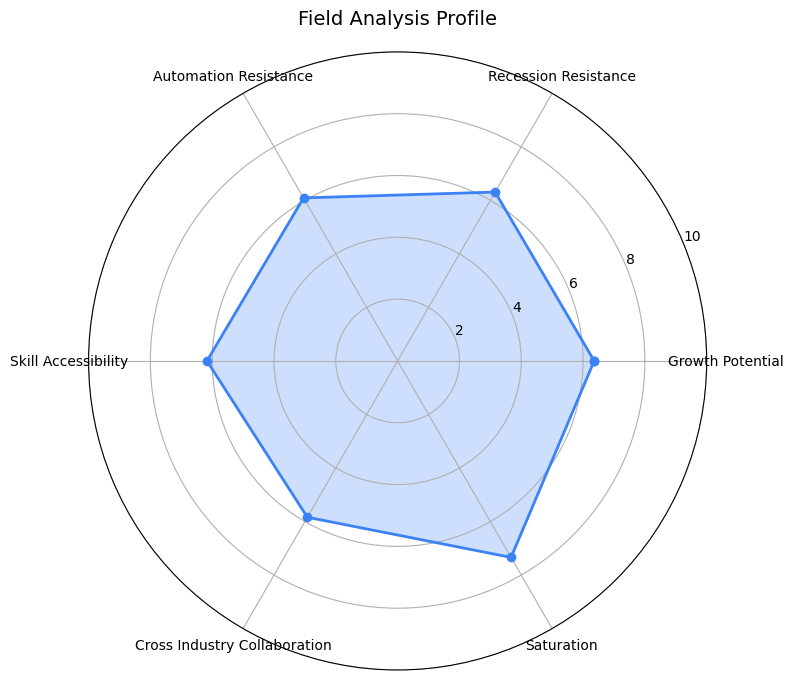

In [50]:
# Initialize and train
analyzer = MultiDimensionalFieldAnalyzer(use_forest=True)

# Load labeled data
df = pd.read_csv('labeled_fields.csv')
texts = df['text'].tolist()
scores = df[analyzer.dimensions]


analyzer.train(texts, scores)

# Predict on new fields
new_fields = {
    'AI Research': 'Artificial intelligence research involves...',
    'Plumbing': 'Plumbers install and repair water systems...',
    'Data Science': 'Data scientists analyze complex datasets...'
}

predictions = analyzer.compare_fields(new_fields)
print(predictions)

# Get top fields for specific dimension
print("\nMost Recession-Resistant Fields:")
print(analyzer.get_top_fields(predictions, 'recession_resistance'))

# Visualize a single field
analyzer.visualize_predictions(
    new_fields['AI Research']
)
plt.savefig('ai_research_profile.png', dpi=300, bbox_inches='tight')

# Save all predictions
predictions.to_csv('field_analysis_results.csv', index=False)

In [51]:
# Advanced: Feature importance and correlation analysis

def analyze_correlations(predictions_df):
    """Analyze correlations between dimensions"""
    import seaborn as sns
    
    corr_matrix = predictions_df[analyzer.dimensions].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix, 
        annot=True, 
        cmap='coolwarm', 
        center=0,
        square=True,
        fmt='.2f'
    )
    plt.title('Dimension Correlations')
    plt.tight_layout()
    plt.savefig('dimension_correlations.png')
    
    return corr_matrix

# Composite scores
def calculate_composite_score(predictions_df, weights=None):
    """
    Calculate weighted composite score
    
    weights: dict mapping dimension to weight (default: equal)
    """
    if weights is None:
        weights = {dim: 1.0 for dim in analyzer.dimensions}
    
    composite = 0
    total_weight = sum(weights.values())
    
    for dim, weight in weights.items():
        composite += predictions_df[dim] * (weight / total_weight)
    
    predictions_df['composite_score'] = composite
    return predictions_df


